# Guidance moves the number more than the architecture does


The atlas refuses to publish a leaderboard, and this notebook is the argument for that decision made
runnable.

Papers routinely report a headline FID and attribute the gap to their contribution. But the sampler
setting alone moves that number by more than most of the architectural gaps being argued about. The
clearest published example is a single table in one paper reporting the identical model at 1.65,
1.49, 1.14 and 1.06 under four different guidance methods, a swing of 0.59 with the weights held
fixed.

We cannot retrain a diffusion transformer here. What we can do is hold one model completely fixed,
vary only the guidance, and watch how far the output moves. If a knob you set at sampling time
changes the image this much, a benchmark number quoted without it is not telling you what you think.

Runs in a couple of minutes on one GPU. Outputs below are from an NVIDIA A100 80GB.


---


**What this notebook uses, and who made it**

| Component | Source |
|---|---|
| Stable Diffusion 1.5 | [runwayml/stable-diffusion-v1-5](https://huggingface.co/runwayml/stable-diffusion-v1-5) |
| Classifier-free guidance | [Ho and Salimans](https://arxiv.org/abs/2207.12598) |
| `diffusers` | [huggingface/diffusers](https://github.com/huggingface/diffusers) |
| CLIP, used here only as a prompt-adherence measure | [openai/clip-vit-base-patch32](https://huggingface.co/openai/clip-vit-base-patch32) |

Related atlas reading: [why the benchmark numbers cannot rank the approaches](/compare) and
[the guidance and sampling line](/lines/line-guidance-sampling).


In [1]:
import torch, numpy as np, matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

DEV = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEV == "cuda" else torch.float32
print(f"device: {DEV}", f"| gpu: {torch.cuda.get_device_name(0)}" if DEV == "cuda" else "")

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", torch_dtype=DTYPE,
    safety_checker=None, local_files_only=True,
).to(DEV)
pipe.set_progress_bar_config(disable=True)

PROMPT = "a photograph of an astronaut riding a horse on a beach at sunset"
SEED = 1234
print("model, prompt and seed are fixed for everything below.")

/home/exx/anaconda3/envs/dediffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | gpu: NVIDIA A100 80GB PCIe


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/196 [00:00<00:00, 632.53it/s, Materializing param=text_model.embeddings.position_embedding.weight]

...

Loading pipeline components...:  67%|██████▋   | 4/6 [00:01<00:00,  3.29it/s]

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  3.82it/s]

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  3.64it/s]


You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


model, prompt and seed are fixed for everything below.


## One model, one prompt, one seed. Only the guidance scale changes.

Nothing about the network differs between these images. Same weights, same prompt, same noise. The
only variable is how far the sampler extrapolates away from the unconditional prediction.

In [2]:
SCALES = [1.0, 2.0, 3.5, 5.0, 7.5, 12.0, 20.0]
images = []
for s in SCALES:
    g = torch.Generator(DEV).manual_seed(SEED)
    images.append(pipe(PROMPT, num_inference_steps=40, guidance_scale=s, generator=g).images[0])
    print(f"guidance {s:5.1f}: done")

guidance   1.0: done


guidance   2.0: done


guidance   3.5: done


guidance   5.0: done


guidance   7.5: done


guidance  12.0: done


guidance  20.0: done


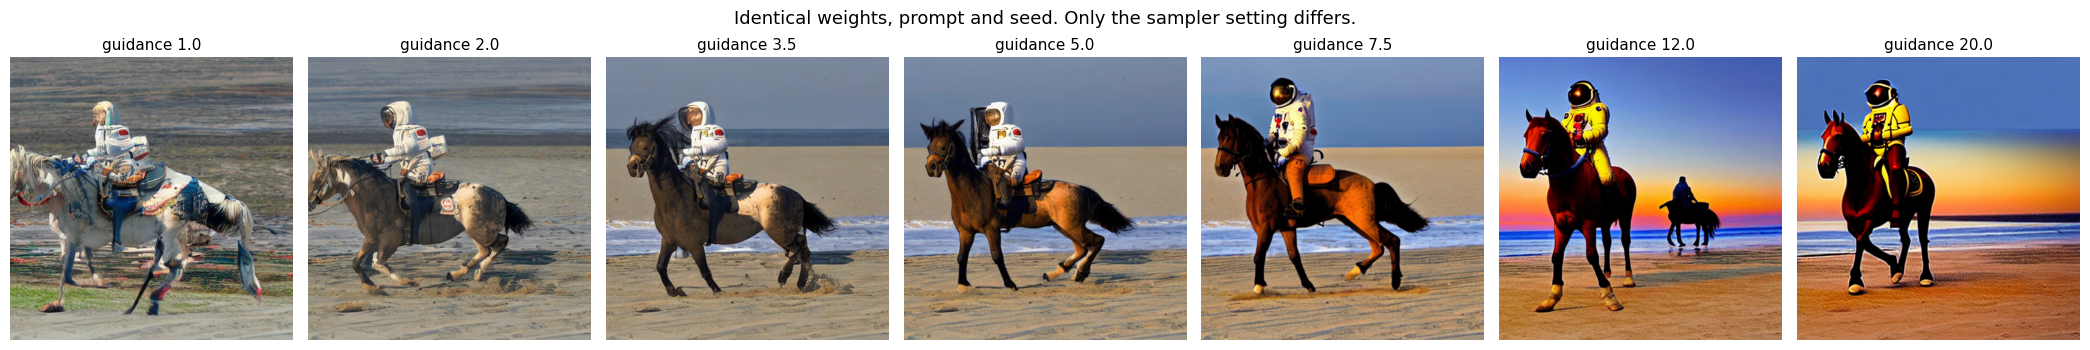

In [3]:
fig, axes = plt.subplots(1, len(SCALES), figsize=(3 * len(SCALES), 3.6))
for ax, s, im in zip(axes, SCALES, images):
    ax.imshow(im); ax.set_title(f"guidance {s}", fontsize=11); ax.axis("off")
plt.suptitle("Identical weights, prompt and seed. Only the sampler setting differs.", fontsize=13)
plt.tight_layout(); plt.show()

At guidance 1.0 the model essentially ignores the prompt. By 7.5 it follows it closely.
By 20 it is over-saturated and losing plausibility.

These are not small differences. If you were shown two of these images and told one came from a
better architecture, you would probably believe it.

## Now measure it

Judging by eye is what the field tries to avoid, so let us put numbers on it. We use two cheap
proxies: CLIP similarity between image and prompt, which stands in for prompt adherence, and the
distance from the guidance-1.0 image, which measures how far the sampler setting alone has moved the
output.

In [4]:
from transformers import CLIPProcessor, CLIPModel

clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", local_files_only=True).to(DEV).eval()
proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32", local_files_only=True)

@torch.no_grad()
def clip_score(img, text):
    inp = proc(text=[text], images=img, return_tensors="pt", padding=True).to(DEV)
    out = clip(**inp)
    i = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
    t = out.text_embeds / out.text_embeds.norm(dim=-1, keepdim=True)
    return float((i @ t.T).squeeze())

base = np.asarray(images[0], np.float64)
scores = [clip_score(im, PROMPT) for im in images]
drift = [float(np.abs(np.asarray(im, np.float64) - base).mean()) for im in images]

print(f"{'guidance':>9} {'CLIP score':>11} {'pixel drift from g=1.0':>24}")
for s, c, d in zip(SCALES, scores, drift):
    print(f"{s:9.1f} {c:11.4f} {d:24.1f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/398 [00:00<00:00, 45590.26it/s, Materializing param=logit_scale]

Loading weights:   0%|          | 1/398 [00:00<00:00, 771.30it/s, Materializing param=logit_scale]  

Loading weights:   1%|          | 2/398 [00:00<00:00, 436.84it/s, Materializing param=text_model.embeddings.position_embedding.weight]

Loading weights:   1%|          | 2/398 [00:00<00:01, 363.74it/s, Materializing param=text_model.embeddings.position_embedding.weight]

...

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 535.89it/s, Materializing param=visual_projection.weight]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 527.76it/s, Materializing param=visual_projection.weight]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


 guidance  CLIP score   pixel drift from g=1.0
      1.0      0.2894                      0.0
      2.0      0.3531                     20.5
      3.5      0.3626                     32.0
      5.0      0.3878                     35.9
      7.5      0.3891                     45.4
     12.0      0.4141                     56.4
     20.0      0.3983                     56.8


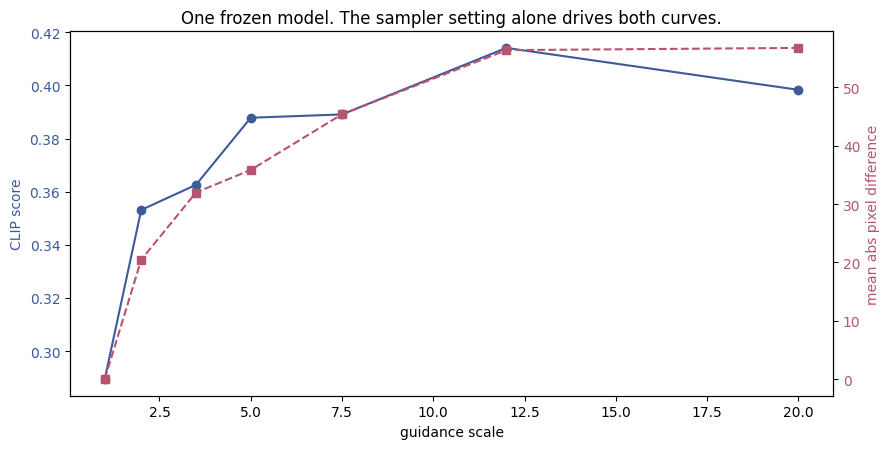


CLIP score spans 0.1247 across guidance settings, on a single frozen model.


In [5]:
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(SCALES, scores, "o-", color="#3d5a99", label="CLIP score (prompt adherence)")
ax1.set_xlabel("guidance scale"); ax1.set_ylabel("CLIP score", color="#3d5a99")
ax1.tick_params(axis="y", labelcolor="#3d5a99")

ax2 = ax1.twinx()
ax2.plot(SCALES, drift, "s--", color="#b8546f", label="pixel drift from guidance 1.0")
ax2.set_ylabel("mean abs pixel difference", color="#b8546f")
ax2.tick_params(axis="y", labelcolor="#b8546f")

plt.title("One frozen model. The sampler setting alone drives both curves.", fontsize=12)
fig.tight_layout(); plt.show()

span = max(scores) - min(scores)
print(f"\nCLIP score spans {span:.4f} across guidance settings, on a single frozen model.")

## Why this decides how the atlas reports numbers

Prompt adherence rises steeply and then flattens or falls, while the image keeps moving. The peak
sits somewhere in the middle, and where exactly depends on the prompt, the sampler and the step
count.

Now consider what that means for a published comparison. A paper reports its method at its
best-tuned guidance against a baseline at that baseline's default. Both numbers are real. The gap
between them is not attributable to the method.

This is not hypothetical. In the ImageNet results the atlas tracks:

- One paper reports the same model at 1.65, 1.49, 1.14 and 1.06 under four guidance methods. That
  0.59 swing is larger than the gap between most competing architectures in the same table.
- The pixel-space result frequently cited as evidence that tokenizers are unnecessary uses roughly
  2B parameters against 675M to 839M for the latent models it is compared with, and a different
  guidance technique, so two confounds move at once.
- Three separate papers report the same public checkpoint at 0.66, 0.67 and 0.82 on the same
  text-to-image benchmark, purely from differences in prompt rewriting and sampler settings.

So the [comparison page](/compare) records the guidance method, training budget and parameter count
beside every number, and leads with what the numbers cannot support rather than with a ranking. Not
out of caution, but because a table that hides these columns is making a claim its own data does not
carry.

**The practical rule:** before believing a headline, check three columns. Guidance method, training
budget, parameter count. If any differs from the baseline, the gap is not evidence for the idea being
sold. The within-paper ablation, where those are held fixed, is almost always the more informative
number, and almost always smaller than the abstract implies.